# Initialisation

In [1]:
import os
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# Path configuaration

In [2]:
RAW_PATH    = "/kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy/augmented_resized_V2"
BASE_PATH   = Path(RAW_PATH)          # single source of truth — no more BASE_PATH vs RAW_PATH confusion
SPLITS      = ['train', 'val', 'test']
CLASSES     = ['0', '1', '2', '3', '4']
CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

# AUDIT

In [3]:
def get_split_stats(split_name: str) -> pd.DataFrame:
    path = BASE_PATH / split_name
    if not path.exists():
        print(f"⚠️  Warning: {path} does not exist. Run !ls /kaggle/input/ to verify.")
        return pd.DataFrame()

    rows = []
    for cls in CLASSES:
        folder = path / cls
        if folder.exists():
            rows.append({
                'Split': split_name,
                'Grade': int(cls),
                'Name':  CLASS_NAMES[int(cls)],
                'Count': len(os.listdir(folder)),
            })
    return pd.DataFrame(rows)

# DATASET → DATAFRAME HELPER

In [4]:
def get_dataset_as_dataframe(base_path: Path) -> pd.DataFrame:
    """Walk every split/class folder and return one row per image."""
    rows = []
    for split in SPLITS:
        for cls in CLASSES:
            folder = base_path / split / cls
            if folder.exists():
                for fname in os.listdir(folder):
                    rows.append({
                        'filepath':       str(folder / fname),
                        'split':          split,
                        'level':          int(cls),
                        'diagnosis_name': CLASS_NAMES[int(cls)],
                    })
    return pd.DataFrame(rows)

# RUN AUDIT

✅ Audit complete — use this table in your 'Materials' section:
Split                test  train   val
Grade Name                            
0     No DR          6896  55162  6895
1     Mild           1862  18470  1840
2     Moderate       2999  24198  3024
3     Severe          978   7936  1000
4     Proliferative  1466   9475  1468


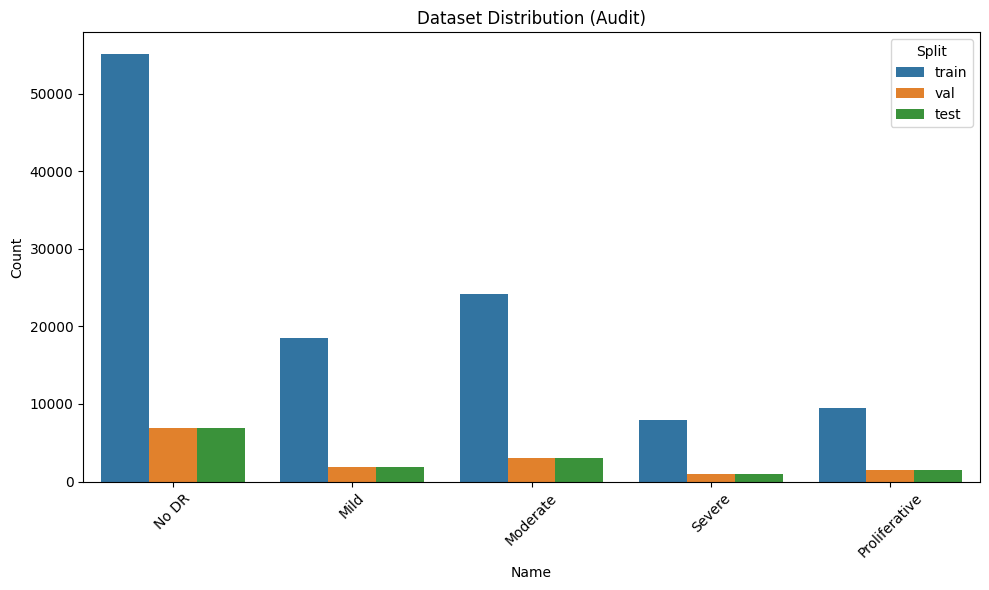

In [5]:
stats_list = [get_split_stats(s) for s in SPLITS]
stats_list = [d for d in stats_list if not d.empty]

if not stats_list:
    raise RuntimeError("❌ No data found. Check your Kaggle dataset path.")

full_stats = pd.concat(stats_list, ignore_index=True)

audit_table = (
    full_stats
    .pivot(index=['Grade', 'Name'], columns='Split', values='Count')
    .fillna(0).astype(int)
)
print("✅ Audit complete — use this table in your 'Materials' section:")
print(audit_table)

# Quick balance check
plt.figure(figsize=(10, 6))
sns.barplot(x='Name', y='Count', hue='Split', data=full_stats)
plt.title("Dataset Distribution (Audit)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# BUILD df


⏳ Scanning folders to build full dataframe …

--- ✅ Dataset Statistics for Journal Table 1 (Global) ---
   DR_Grade  Count  Percentage
0         0  68953   47.994348
1         1  22172   15.432696
2         2  30221   21.035157
3         3   9914    6.900584
4         4  12409    8.637215

--- ✅ Split Breakdown ---
split                 test  train   val
level diagnosis_name                   
0     No DR           6896  55162  6895
1     Mild            1862  18470  1840
2     Moderate        2999  24198  3024
3     Severe           978   7936  1000
4     Proliferative   1466   9475  1468


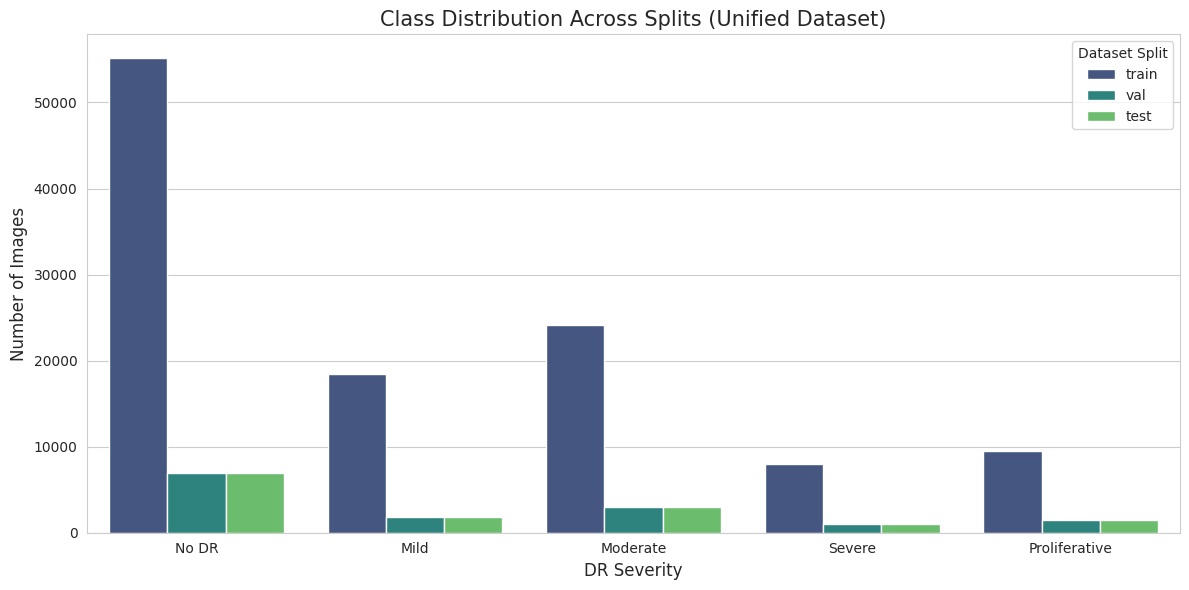

In [6]:
print("\n⏳ Scanning folders to build full dataframe …")
df = get_dataset_as_dataframe(BASE_PATH)

if df.empty:
    raise RuntimeError("❌ No images found. Verify the dataset is attached correctly.")

# Global statistics
stats = df['level'].value_counts().sort_index().reset_index()
stats.columns = ['DR_Grade', 'Count']
stats['Percentage'] = (stats['Count'] / len(df)) * 100
print("\n--- ✅ Dataset Statistics for Journal Table 1 (Global) ---")
print(stats)

# Per-split breakdown
split_audit = (
    df.groupby(['level', 'diagnosis_name', 'split'])
    .size()
    .unstack(fill_value=0)
)
print("\n--- ✅ Split Breakdown ---")
print(split_audit)

# Countplot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.countplot(x='diagnosis_name', hue='split', data=df, palette='viridis')
plt.title("Class Distribution Across Splits (Unified Dataset)", fontsize=15)
plt.xlabel("DR Severity", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.legend(title="Dataset Split")
plt.tight_layout()
plt.show()

# PERCENTAGE DISTRIBUTION 

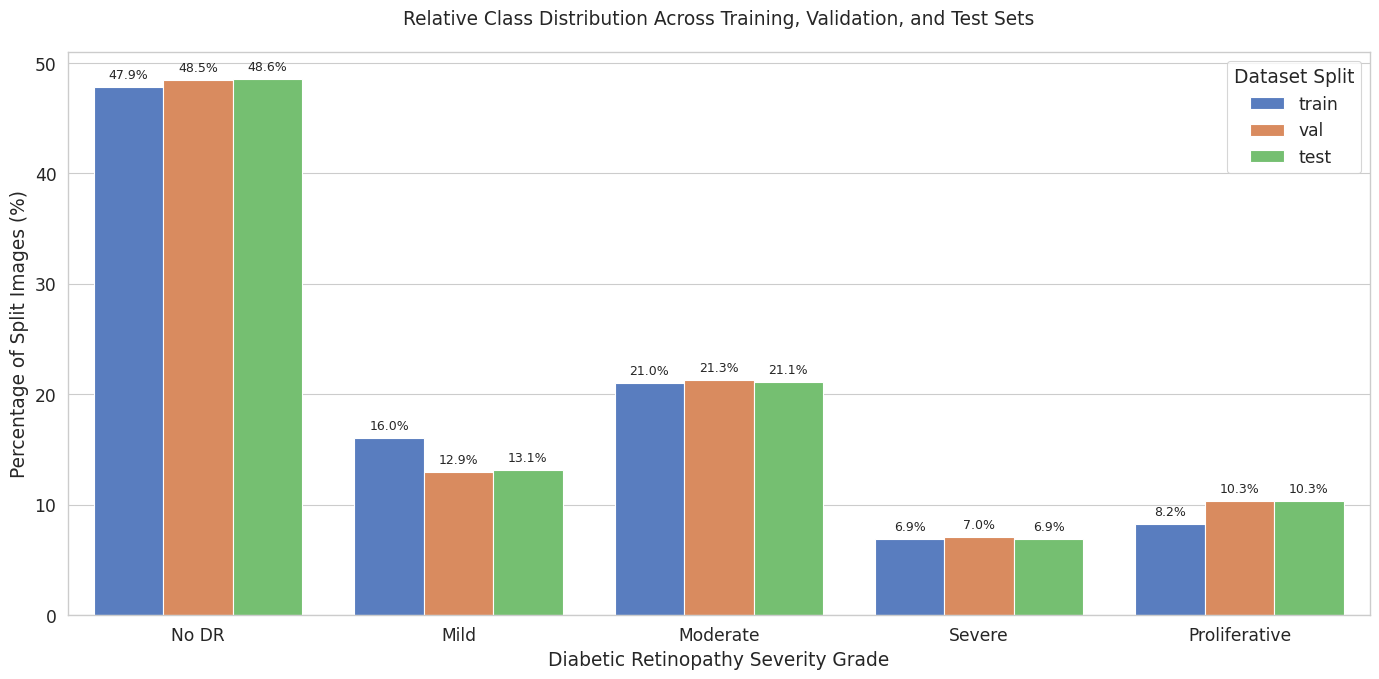

In [7]:
# Add a Percentage column to full_stats so each split sums to 100 %
full_stats['Percentage'] = full_stats.groupby('Split')['Count'].transform(
    lambda x: (x / x.sum()) * 100
)

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.4)

ax = sns.barplot(x='Name', y='Percentage', hue='Split', data=full_stats, palette='muted')
plt.title("Relative Class Distribution Across Training, Validation, and Test Sets", pad=20)
plt.ylabel("Percentage of Split Images (%)")
plt.xlabel("Diabetic Retinopathy Severity Grade")
plt.legend(title="Dataset Split", frameon=True)

# Annotate bars — use actual float values formatted to 1 decimal place
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f'{h:.1f}%',
            (p.get_x() + p.get_width() / 2., h),
            ha='center', va='bottom',
            xytext=(0, 4), textcoords='offset points',
            fontsize=9,
        )

plt.tight_layout()
plt.savefig('distribution_audit.png', dpi=300)
plt.show()

# SAMPLE VISUALISATION

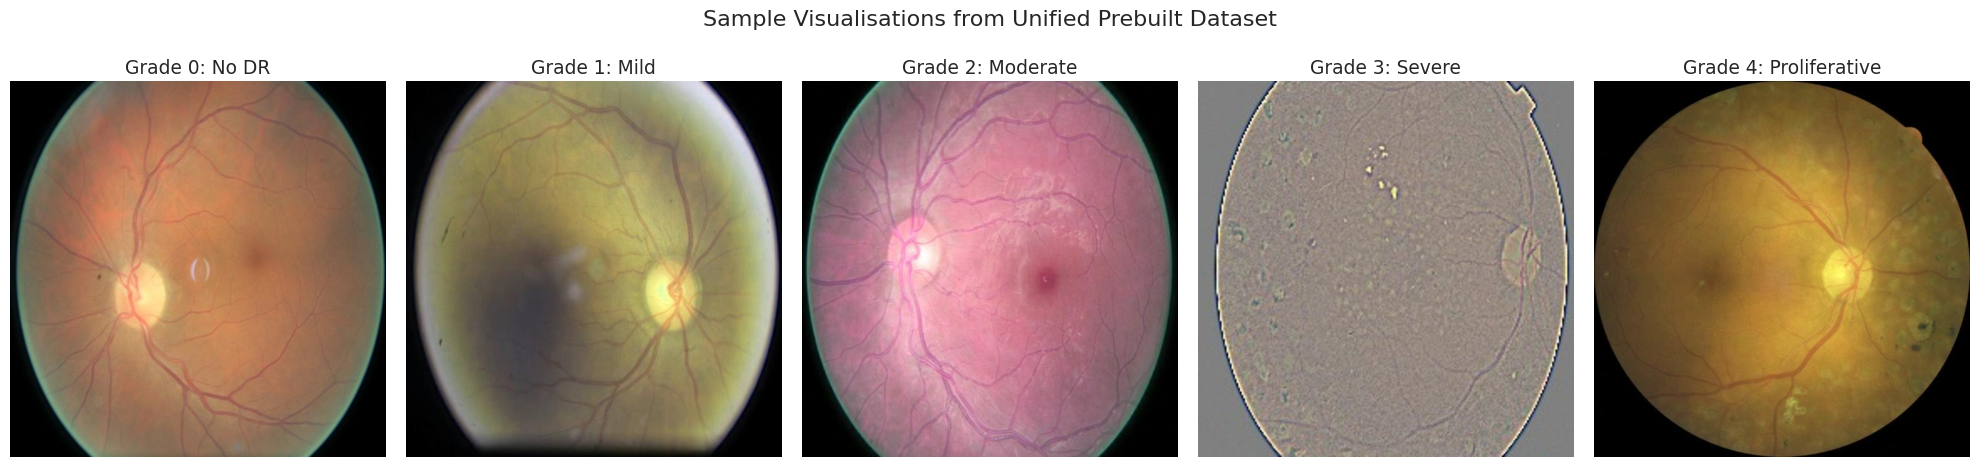

In [8]:
def plot_samples(num_per_class: int = 1):
    fig, axes = plt.subplots(1, len(CLASSES), figsize=(20, 5))
    for i, cls in enumerate(CLASSES):
        folder = BASE_PATH / 'train' / cls
        if not folder.exists() or not os.listdir(folder):
            axes[i].set_title(f"Grade {cls}: missing")
            axes[i].axis('off')
            continue

        img_name = random.choice(os.listdir(folder))
        img      = cv2.imread(str(folder / img_name))
        img      = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img)
        axes[i].set_title(f"Grade {cls}: {CLASS_NAMES[i]}")
        axes[i].axis('off')

    plt.suptitle("Sample Visualisations from Unified Prebuilt Dataset", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_samples()

# Imbalance Metrics

In [9]:
import torch

CLASS_NAMES  = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
ALL_GRADES   = [0, 1, 2, 3, 4]
SPLITS       = ['train', 'val', 'test']
BETA_CB      = 0.9999   # for Class-Balanced loss effective number


def calculate_imbalance_metrics(dataframe: pd.DataFrame, split_name: str = "Global") -> dict:
    """
    Returns imbalance statistics for one split (or the full dataset).

    Additions over the original:
    - reindex so missing grades show as 0 (avoids silent weight errors)
    - Gini impurity as a single balance score (0 = perfect balance, 1 = all one class)
    - Effective number of samples per class (for CB Loss)
    - PyTorch weight tensor ready for nn.CrossEntropyLoss
    """
    if split_name != "Global":
        subset = dataframe[dataframe['split'] == split_name]
    else:
        subset = dataframe

    # Reindex so every grade is always present, even if count = 0
    counts = (
        subset['level']
        .value_counts()
        .reindex(ALL_GRADES, fill_value=0)
        .sort_index()
    )

    total      = counts.sum()
    n_classes  = len(counts)
    n_max      = counts.max()
    n_min      = counts[counts > 0].min()          # ignore empty classes for IR
    maj_class  = counts.idxmax()
    min_class  = counts[counts > 0].idxmin()

    # Imbalance ratio
    ir = round(n_max / n_min, 2) if n_min > 0 else float('inf')

    # Inverse-frequency class weights  (safe: add epsilon for empty classes)
    eps     = 1e-6
    weights = total / (n_classes * (counts + eps))

    # Gini impurity  (0 = perfectly balanced, approaches 1 = maximally imbalanced)
    proportions = counts / (total + eps)
    gini        = float(1.0 - (proportions ** 2).sum())

    # Effective number of samples (Class-Balanced Loss, Cui et al. 2019)
    # E_n = (1 - beta^n) / (1 - beta)
    eff_num = (1.0 - BETA_CB ** counts) / (1.0 - BETA_CB + eps)
    cb_weights = 1.0 / (eff_num + eps)
    cb_weights = cb_weights / cb_weights.sum() * n_classes   # normalise to sum to n_classes

    # PyTorch tensors (float32, CPU — move to device in training loop)
    weight_tensor    = torch.tensor(weights.values,    dtype=torch.float32)
    cb_weight_tensor = torch.tensor(cb_weights.values, dtype=torch.float32)

    return {
        "split":          split_name,
        "counts":         counts.to_dict(),
        "total":          int(total),
        "ir":             ir,
        "maj_class":      int(maj_class),
        "min_class":      int(min_class),
        "n_maj":          int(n_max),
        "n_min":          int(n_min),
        "gini":           round(gini, 4),
        "inv_freq_weights":  [round(w, 4) for w in weights.values],
        "cb_weights":        [round(w, 4) for w in cb_weights.values],
        "weight_tensor":     weight_tensor,       # drop into CrossEntropyLoss
        "cb_weight_tensor":  cb_weight_tensor,    # alternative: CB Loss weights
    }


def print_imbalance_report(df: pd.DataFrame) -> None:
    """Prints a tidy summary table across all splits plus global."""
    rows = []
    for split in ["Global"] + SPLITS:
        m = calculate_imbalance_metrics(df, split)
        rows.append({
            "Split":       m["split"],
            "Total":       m["total"],
            "IR":          m["ir"],
            "Gini":        m["gini"],
            "Maj class":   f"Grade {m['maj_class']} ({m['n_maj']:,})",
            "Min class":   f"Grade {m['min_class']} ({m['n_min']:,})",
        })

    summary = pd.DataFrame(rows).set_index("Split")
    print("=" * 70)
    print("  Imbalance Report")
    print("=" * 70)
    print(summary.to_string())
    print()

    # Print ready-to-use weight tensors for the training split
    train_m = calculate_imbalance_metrics(df, "train")
    print("  Inverse-frequency weights (train):")
    for i, (name, w) in enumerate(zip(CLASS_NAMES, train_m["inv_freq_weights"])):
        print(f"    Grade {i} ({name:<14}): {w:.4f}")
    print()
    print("  Class-Balanced weights (train, beta=0.9999):")
    for i, (name, w) in enumerate(zip(CLASS_NAMES, train_m["cb_weights"])):
        print(f"    Grade {i} ({name:<14}): {w:.4f}")
    print()
    print("  Usage in training loop:")
    print("    criterion = nn.CrossEntropyLoss(")
    print("        weight=train_metrics['weight_tensor'].to(device)")
    print("    )")
    print("=" * 70)


# ── Run ───────────────────────────────────────────────────────────────────────
if 'df' not in dir() or df.empty:
    raise RuntimeError("df is not defined — run the dataset scan cell first.")

print_imbalance_report(df)

# Keep individual results for downstream use
global_metrics = calculate_imbalance_metrics(df, "Global")
train_metrics  = calculate_imbalance_metrics(df, "train")
val_metrics    = calculate_imbalance_metrics(df, "val")
test_metrics   = calculate_imbalance_metrics(df, "test")

  Imbalance Report
         Total    IR    Gini         Maj class        Min class
Split                                                          
Global  143669  6.96  0.6894  Grade 0 (68,953)  Grade 3 (9,914)
train   115241  6.95  0.6896  Grade 0 (55,162)  Grade 3 (7,936)
val      14227  6.89  0.6876   Grade 0 (6,895)  Grade 3 (1,000)
test     14201  7.05  0.6870   Grade 0 (6,896)    Grade 3 (978)

  Inverse-frequency weights (train):
    Grade 0 (No DR         ): 0.4178
    Grade 1 (Mild          ): 1.2479
    Grade 2 (Moderate      ): 0.9525
    Grade 3 (Severe        ): 2.9043
    Grade 4 (Proliferative ): 2.4325

  Class-Balanced weights (train, beta=0.9999):
    Grade 0 (No DR         ): 0.7440
    Grade 1 (Mild          ): 0.8797
    Grade 2 (Moderate      ): 0.8133
    Grade 3 (Severe        ): 1.3527
    Grade 4 (Proliferative ): 1.2102

  Usage in training loop:
    criterion = nn.CrossEntropyLoss(
        weight=train_metrics['weight_tensor'].to(device)
    )


# Entropy of Class Distribution

Measures randomness / balance: 
> $$H = -\sum_{i=1}^{n} p_i \log p_i$$


In [10]:
import numpy as np

def compute_entropy(counts):
    probs = counts / counts.sum()
    entropy = -np.sum(probs * np.log(probs + 1e-9))
    return entropy

# Global entropy
counts = df['level'].value_counts().sort_index()
entropy = compute_entropy(counts)

print(f"📊 Dataset Entropy: {entropy:.4f}")

📊 Dataset Entropy: 1.3647


# KL Divergence (Train vs Val vs Test) and Dataset Similarity Heatmap

📊 KL Divergence Matrix:
          train       val      test
train       0.0  0.005795  0.005379
val    0.005738       0.0  0.000032
test   0.005364  0.000032       0.0


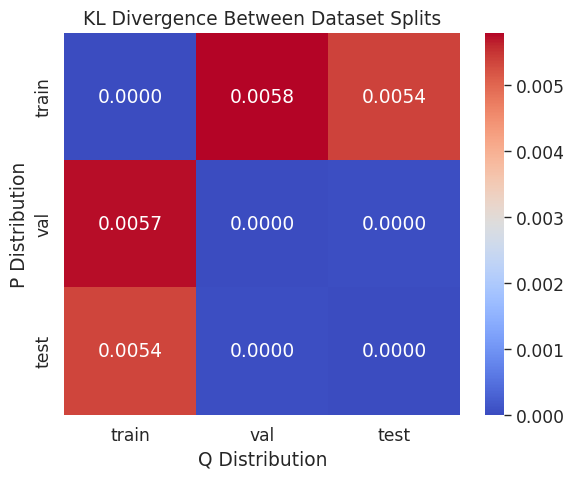

In [11]:
def get_distribution(df, split):
    dist = (
        df[df['split'] == split]['level']
        .value_counts(normalize=True)
        .reindex([0,1,2,3,4], fill_value=0)
        .sort_index()
    )
    return dist.values

def kl_divergence(p, q):
    return np.sum(p * np.log((p + 1e-9) / (q + 1e-9)))

splits = ['train', 'val', 'test']
kl_matrix = pd.DataFrame(index=splits, columns=splits)

for s1 in splits:
    for s2 in splits:
        p = get_distribution(df, s1)
        q = get_distribution(df, s2)
        kl_matrix.loc[s1, s2] = kl_divergence(p, q)

print("📊 KL Divergence Matrix:")
print(kl_matrix)

#-----------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(kl_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".4f")
plt.title("KL Divergence Between Dataset Splits")
plt.ylabel("P Distribution")
plt.xlabel("Q Distribution")
plt.tight_layout()
plt.show()

# Image Quality Metrics (Brightness, Contrast, Sharpness)

In [12]:
import cv2
from tqdm import tqdm

def compute_image_stats(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness = np.mean(gray)
    contrast = np.std(gray)
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()

    return brightness, contrast, sharpness

# Sample subset for speed (important)
sample_df = df.sample(n=2000, random_state=42)

brightness_list, contrast_list, sharpness_list = [], [], []

for path in tqdm(sample_df['filepath']):
    b, c, s = compute_image_stats(path)
    brightness_list.append(b)
    contrast_list.append(c)
    sharpness_list.append(s)

quality_df = pd.DataFrame({
    'brightness': brightness_list,
    'contrast': contrast_list,
    'sharpness': sharpness_list,
    'class': sample_df['diagnosis_name'].values
})

100%|██████████| 2000/2000 [00:33<00:00, 59.10it/s]


## Graph

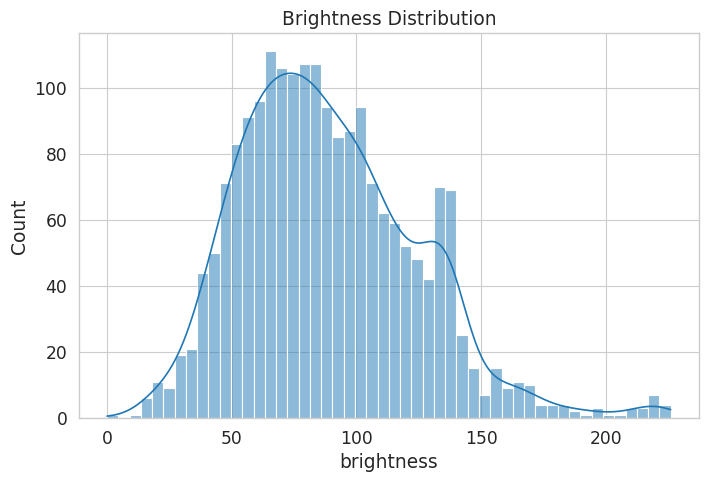

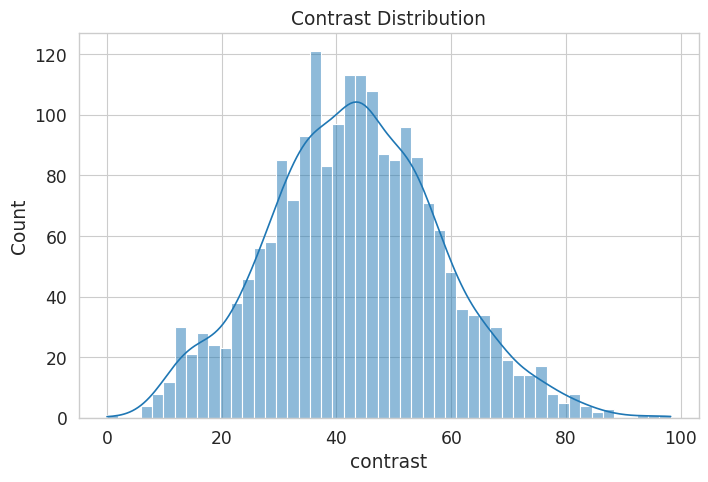

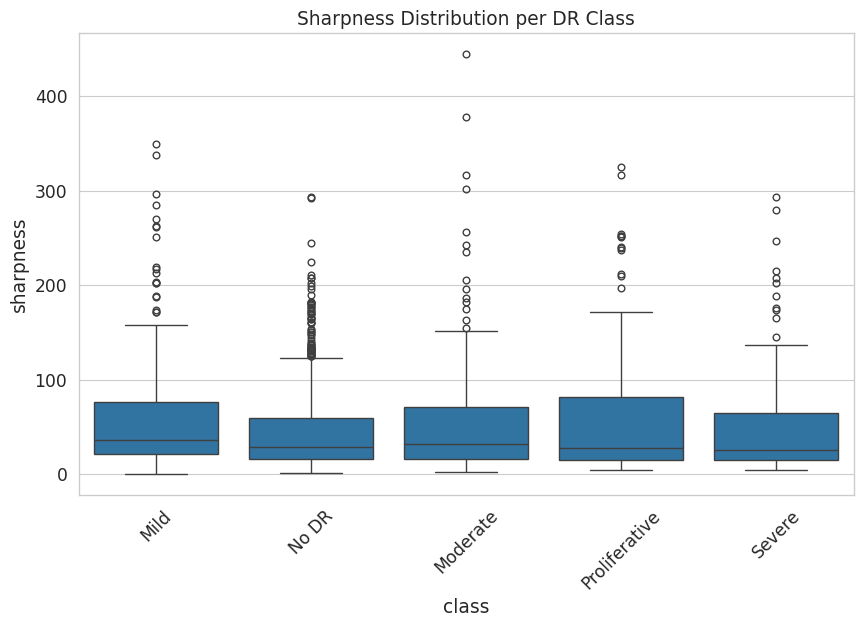

In [13]:
# Brightness
plt.figure(figsize=(8,5))
sns.histplot(quality_df['brightness'], bins=50, kde=True)
plt.title("Brightness Distribution")
plt.show()

# Contrast
plt.figure(figsize=(8,5))
sns.histplot(quality_df['contrast'], bins=50, kde=True)
plt.title("Contrast Distribution")
plt.show()

# Sharpness per class
plt.figure(figsize=(10,6))
sns.boxplot(x='class', y='sharpness', data=quality_df)
plt.xticks(rotation=45)
plt.title("Sharpness Distribution per DR Class")
plt.show()

# t-SNE Visualization

100%|██████████| 1500/1500 [00:04<00:00, 302.19it/s]


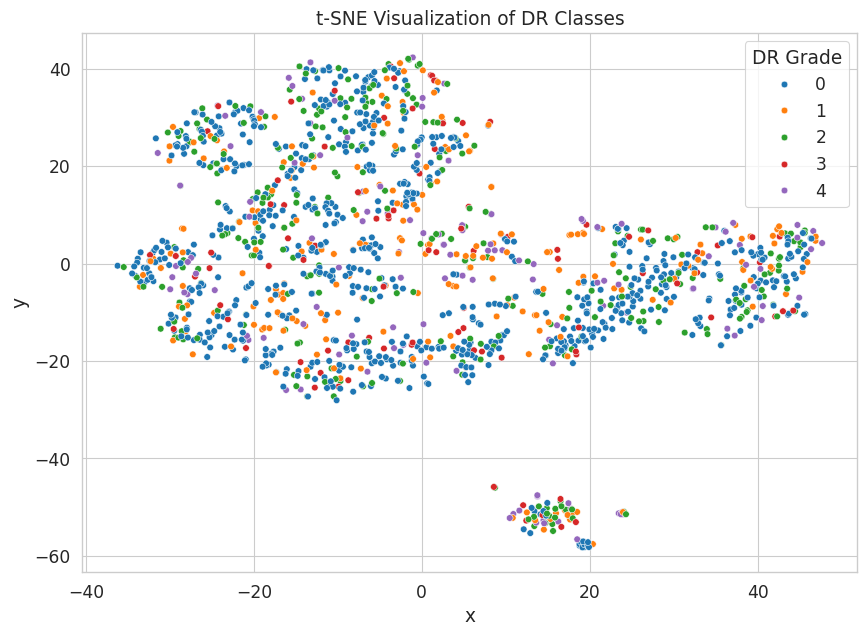

In [14]:
from sklearn.manifold import TSNE

# Sample data
sample_df = df.sample(n=1500, random_state=42)

features = []
labels = []

for path, label in tqdm(zip(sample_df['filepath'], sample_df['level']), total=len(sample_df)):
    img = cv2.imread(path)
    img = cv2.resize(img, (64,64))  # reduce size
    features.append(img.flatten())
    labels.append(label)

features = np.array(features)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings = tsne.fit_transform(features)

tsne_df = pd.DataFrame({
    'x': embeddings[:,0],
    'y': embeddings[:,1],
    'label': labels
})

plt.figure(figsize=(10,7))
sns.scatterplot(x='x', y='y', hue='label', palette='tab10', data=tsne_df)
plt.title("t-SNE Visualization of DR Classes")
plt.legend(title="DR Grade")
plt.show()

# Duplicates/Data Leakage Check

In [15]:
import os
import hashlib
from tqdm import tqdm

# Stage 1: size filter (seconds)
df['file_size'] = df['filepath'].apply(os.path.getsize)
candidates = df[df.duplicated('file_size', keep=False)].copy()
print(f"Size collisions to check: {len(candidates)} / {len(df)}")

# Stage 2: partial hash only on collisions
def partial_hash(path, chunk=8192):
    h = hashlib.md5()
    size = os.path.getsize(path)
    with open(path, 'rb') as f:
        h.update(f.read(chunk))
        if size > chunk:
            f.seek(-chunk, 2)
            h.update(f.read(chunk))
    return h.hexdigest()

if len(candidates) > 0:
    tqdm.pandas()
    candidates['phash'] = candidates['filepath'].progress_apply(partial_hash)
    duplicates    = candidates.duplicated('phash').sum()
    dup_groups    = candidates[candidates.duplicated('phash', keep=False)]
    leakage       = dup_groups.groupby('phash')['split'].nunique()
    leakage_count = (leakage > 1).sum()
else:
    duplicates, leakage_count = 0, 0

print(f"Duplicate images:          {duplicates}")
print(f"Cross-split leakage cases: {leakage_count}")

# Clean up — don't carry file_size into downstream cells
df.drop(columns=['file_size'], inplace=True)

Size collisions to check: 134773 / 143669


100%|██████████| 134773/134773 [17:05<00:00, 131.47it/s]


Duplicate images:          455
Cross-split leakage cases: 82


# Lorenz Curve (Class Imbalance)

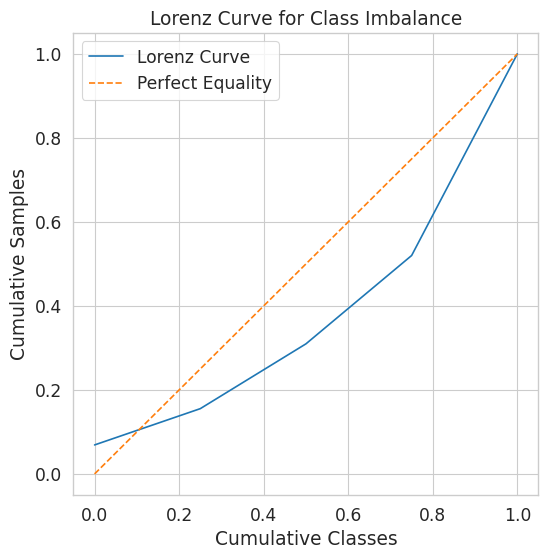

In [16]:
def plot_lorenz_curve(counts):
    sorted_counts = np.sort(counts)
    cum_counts = np.cumsum(sorted_counts)
    cum_counts = cum_counts / cum_counts[-1]

    x = np.linspace(0, 1, len(cum_counts))

    plt.figure(figsize=(6,6))
    plt.plot(x, cum_counts, label='Lorenz Curve')
    plt.plot([0,1], [0,1], linestyle='--', label='Perfect Equality')
    plt.title("Lorenz Curve for Class Imbalance")
    plt.xlabel("Cumulative Classes")
    plt.ylabel("Cumulative Samples")
    plt.legend()
    plt.show()

counts = df['level'].value_counts().values
plot_lorenz_curve(counts)

# Cumulative Distribution Plot

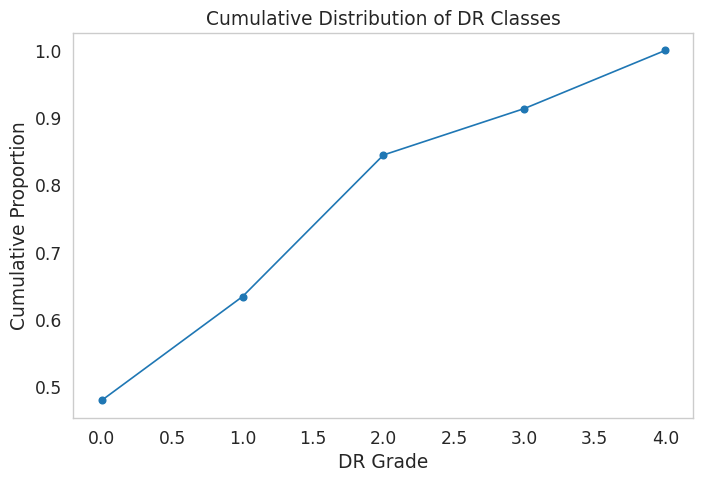

In [17]:
counts = df['level'].value_counts().sort_index()
cum_dist = counts.cumsum() / counts.sum()

plt.figure(figsize=(8,5))
plt.plot(cum_dist.index, cum_dist.values, marker='o')
plt.title("Cumulative Distribution of DR Classes")
plt.xlabel("DR Grade")
plt.ylabel("Cumulative Proportion")
plt.grid()
plt.show()